**1. Instalasi Library & Impor Modul**

In [3]:
# Instalasi library yang dibutuhkan jika belum ada
!pip install gdown -q

# Impor library utama
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Impor library Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import tensorflow as tf
from tensorflow.keras import layers, callbacks, models, regularizers

**2. Mengunduh dan Memuat Data**

In [4]:
# Download file dari Google Drive
# Pastikan URL dapat diakses secara publik
gdown.download('https://drive.google.com/uc?id=1oEXSD137hPm_Fx5xSPRvlAr3silj3suK', 'data.csv', quiet=False)

# 1.1. Baca data ke dalam DataFrame
df = pd.read_csv('data.csv')

# Tampilkan 5 baris pertama data untuk inspeksi
print("Data Awal:")
print(df.head())

Downloading...
From (original): https://drive.google.com/uc?id=1oEXSD137hPm_Fx5xSPRvlAr3silj3suK
From (redirected): https://drive.google.com/uc?id=1oEXSD137hPm_Fx5xSPRvlAr3silj3suK&confirm=t&uuid=6037cca5-d84a-4348-839f-29a3554297b0
To: /content/data.csv
100%|██████████| 443M/443M [00:06<00:00, 65.7MB/s]


Data Awal:
   2001  49.94357  21.47114   73.0775   8.74861  -17.40628  -13.09905  \
0  2001  48.73215  18.42930  70.32679  12.94636  -10.32437  -24.83777   
1  2001  50.95714  31.85602  55.81851  13.41693   -6.57898  -18.54940   
2  2001  48.24750  -1.89837  36.29772   2.58776    0.97170  -26.21683   
3  2001  50.97020  42.20998  67.09964   8.46791  -15.85279  -16.81409   
4  2001  50.54767   0.31568  92.35066  22.38696  -25.51870  -19.04928   

   -25.01202  -12.23257   7.83089  ...   13.0162  -54.40548  58.99367  \
0    8.76630   -0.92019  18.76548  ...   5.66812  -19.68073  33.04964   
1   -3.27872   -2.35035  16.07017  ...   3.03800   26.05866 -50.92779   
2    5.05097  -10.34124   3.55005  ...  34.57337 -171.70734 -16.96705   
3  -12.48207   -9.37636  12.63699  ...   9.92661  -55.95724  64.92712   
4   20.67345   -5.19943   3.63566  ...   6.59753  -50.69577  26.02574   

   15.37344   1.11144  -23.08793   68.40795  -1.82223  -27.46348   2.26327  
0  42.87836  -9.90378  -32.22788  

**3. Pembersihan dan Pemisahan Data**

In [5]:
# 1.2. Bersihkan data
df = df.dropna()  # Buang baris dengan nilai yang hilang
# Hilangkan spasi di awal/akhir pada kolom kategorikal
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# 1.3. Pisahkan fitur (X) dan target (y)
X = df.drop(df.columns[0], axis=1)  # Semua kolom kecuali yang pertama sebagai fitur
y = df.iloc[:, 0].astype('int')      # Kolom pertama sebagai target

# 1.4. Split data menjadi data latih (train) dan data uji (test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Ukuran Data Latih (X_train): {X_train.shape}")
print(f"Ukuran Data Uji (X_test): {X_test.shape}")

Ukuran Data Latih (X_train): (412275, 90)
Ukuran Data Uji (X_test): (103069, 90)


**4. Preprocessing**

In [6]:
# Definisikan kolom numerik dan kategorikal
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object','category']).columns

# Pipeline untuk memproses data numerik: penskalaan standar
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Pipeline untuk memproses data kategorikal: One-Hot Encoding
cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

# Gabungkan kedua pipeline menggunakan ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
], remainder='passthrough')

# Terapkan preprocessor ke data latih dan data uji
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Konversi hasil sparse matrix (jika ada) ke dense array
if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
    X_test_proc = X_test_proc.toarray()

print(f"Ukuran data latih setelah diproses: {X_train_proc.shape}")

Ukuran data latih setelah diproses: (412275, 90)


**5. Model TensorFlow/Keras - Definisi dan Pelatihan**

In [8]:
# Fungsi untuk membangun model Sequential Keras
def build_tf_model(input_shape):
    inputs = layers.Input(shape=(input_shape,))
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1)(x)
    model = models.Model(inputs, outputs)
    return model

# Bangun model
model_tf = build_tf_model(X_train_proc.shape[1])
model_tf.summary()

# Callback untuk Early Stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True)

# Kompilasi model
model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

# Latih model
history_tf = model_tf.fit(
    X_train_proc, y_train,
    validation_split=0.2, # 20% dari data latih untuk validasi
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 90)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        11,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,737 (81.00 KB)

 Trainable params: 20,353 (79.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
10307/10307 - 42s - 4ms/step - loss: 877200.0000 - mae: 643.6637 - val_loss: 469.8668 - val_mae: 19.2962
Epoch 2/100
10307/10307 - 40s - 4ms/step - loss: 26522.4453 - mae: 129.8594 - val_loss: 236.5242 - val_mae: 13.6497
Epoch 3/100
10307/10307 - 35s - 3ms/step - loss: 26490.8047 - mae: 129.7606 - val_loss: 260.3416 - val_mae: 14.7258
Epoch 4/100
10307/10307 - 33s - 3ms/step - loss: 26217.6855 - mae: 129.1514 - val_loss: 342.0628 - val_mae: 17.2166
Epoch 5/100
10307/10307 - 42s - 4ms/step - loss: 26235.1113 - mae: 129.0689 - val_loss: 216.2477 - val_mae: 13.3545
Epoch 6/100
10307/10307 - 37s - 4ms/step - loss: 26023.5527 - mae: 128.7492 - val_loss: 214.6878 - val_mae: 13.2203
Epoch 7/100
10307/10307 - 38s - 4ms/step - loss: 25856.6953 - mae: 128.0099 - val_loss: 181.8909 - val_mae: 11.9833
Epoch 8/100
10307/10307 - 41s - 4ms/step - loss: 25797.6641 - mae: 128.0078 - val_loss: 269.2619 - val_mae: 15.0968
Epoch 9/100
10307/10307 - 46s - 5ms/step - loss: 25725.1953 - mae: 127.

**6. Model PyTorch - Definisi Kelas dan Persiapan Data**

In [9]:
# Tentukan perangkat (GPU jika tersedia, jika tidak CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Menggunakan perangkat: {device}')

# Definisikan arsitektur MLP
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# Pisahkan data latih menjadi set latih baru dan set validasi
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_proc, y_train, test_size=0.2, random_state=42)

# Konversi ke Tensor PyTorch
X_train_t = torch.tensor(X_train_sub, dtype=torch.float32)
y_train_t = torch.tensor(y_train_sub.values, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_proc, dtype=torch.float32)

# Buat DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_ds = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_ds, batch_size=32)

Menggunakan perangkat: cpu


**7. Model PyTorch - Fungsi Pelatihan dan Eksekusi**

In [11]:
# Inisialisasi model, loss, dan optimizer
model_pt = MLP(X_train_proc.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model_pt.parameters(), lr=1e-3, weight_decay=1e-4)

# Fungsi untuk melatih model PyTorch
def train_model_pt(epochs, model, train_loader, val_loader, optimizer, criterion, patience=15):
    best_val_loss = float('inf')
    patience_trigger = 0

    print(f"Memulai pelatihan untuk maksimal {epochs} epochs...")
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item()
        val_loss /= len(val_loader)

        print(f'Epoch {epoch+1}/{epochs} | Val Loss: {val_loss:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_pt_model.pth')
            patience_trigger = 0
        else:
            patience_trigger += 1
            if patience_trigger >= patience:
                print(f'\nEarly stopping! Tidak ada peningkatan performa dalam {patience} epochs terakhir.')
                break
    print("Pelatihan selesai.")
    return

# Latih model PyTorch dengan jumlah epochs yang lebih sedikit
train_model_pt(15, model_pt, train_loader, val_loader, optimizer, criterion)

Memulai pelatihan untuk maksimal 15 epochs...
Epoch 1/15 | Val Loss: 486.1017
Epoch 2/15 | Val Loss: 279.6903
Epoch 3/15 | Val Loss: 216.7756
Epoch 4/15 | Val Loss: 222.3097
Epoch 5/15 | Val Loss: 370.9516
Epoch 6/15 | Val Loss: 332.6693
Epoch 7/15 | Val Loss: 228.9703
Epoch 8/15 | Val Loss: 157.7569
Epoch 9/15 | Val Loss: 188.3431
Epoch 10/15 | Val Loss: 212.6211
Epoch 11/15 | Val Loss: 206.9830
Epoch 12/15 | Val Loss: 272.0577
Epoch 13/15 | Val Loss: 223.1529
Epoch 14/15 | Val Loss: 142.4001
Epoch 15/15 | Val Loss: 310.7892
Pelatihan selesai.


**8. Evaluasi Akhir dan Visualisasi**

3221/3221 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step

--- Hasil Evaluasi Model pada Data Uji ---
[TensorFlow] MSE=148.5909 | RMSE=12.1898 | R²=-0.2520
[PyTorch] MSE=141.6674 | RMSE=11.9024 | R²=-0.1936


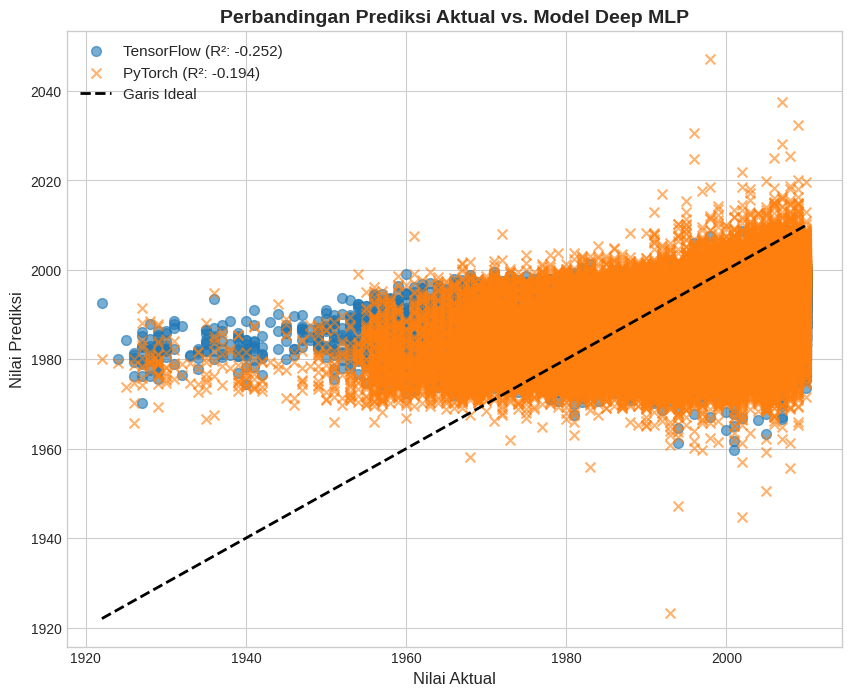

In [12]:
# Prediksi menggunakan data uji (test set)
# TensorFlow
y_pred_tf = model_tf.predict(X_test_proc).flatten()

# PyTorch
model_pt.load_state_dict(torch.load('best_pt_model.pth'))
model_pt.eval()
with torch.no_grad():
    y_pred_pt = model_pt(X_test_t.to(device)).cpu().numpy().flatten()

# Hitung metrik evaluasi
results = {
    'TensorFlow': {
        'mse': mean_squared_error(y_test, y_pred_tf),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred_tf)),
        'r2': r2_score(y_test, y_pred_tf)
    },
    'PyTorch': {
        'mse': mean_squared_error(y_test, y_pred_pt),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred_pt)),
        'r2': r2_score(y_test, y_pred_pt)
    }
}

# Tampilkan hasil
print("\n--- Hasil Evaluasi Model pada Data Uji ---")
for name, metrics in results.items():
    print(f"[{name}] MSE={metrics['mse']:.4f} | RMSE={metrics['rmse']:.4f} | R²={metrics['r2']:.4f}")

# Visualisasi perbandingan hasil prediksi
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_tf, alpha=0.6, label=f'TensorFlow (R²: {results["TensorFlow"]["r2"]:.3f})', s=50)
plt.scatter(y_test, y_pred_pt, alpha=0.6, label=f'PyTorch (R²: {results["PyTorch"]["r2"]:.3f})', s=50, marker='x')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Garis Ideal')
plt.xlabel('Nilai Aktual', fontsize=12)
plt.ylabel('Nilai Prediksi', fontsize=12)
plt.title('Perbandingan Prediksi Aktual vs. Model Deep MLP', fontsize=14, weight='bold')
plt.legend(fontsize=11)
plt.grid(True)
plt.show()

### **Analisis dan Penjelasan Matematis Model Regresi MLP**

Dokumen ini menjelaskan pendekatan matematis dan teknis yang digunakan dalam membangun model regresi *Deep Learning* menggunakan *Multilayer Perceptron* (MLP).

#### **1. Pra-pemrosesan Data (Data Preprocessing)**

Tujuan dari pra-pemrosesan adalah untuk mengubah data mentah menjadi format yang bersih dan optimal untuk pelatihan model. Langkah-langkah yang dilakukan adalah:

* **Pembersihan Data**: Baris data dengan nilai yang hilang (`missing values`) dihapus untuk memastikan kualitas dan integritas data.
* **Penskalaan Fitur Numerik (StandardScaler)**: Fitur numerik memiliki rentang nilai yang berbeda. Untuk mencegah fitur dengan rentang besar mendominasi proses pembelajaran, dilakukan normalisasi menggunakan StandardScaler. Setiap nilai fitur diubah berdasarkan rumus:
    $$x' = \frac{x - \mu}{\sigma}$$
    di mana $x$ adalah nilai asli, $\mu$ adalah rata-rata (mean), dan $\sigma$ adalah standar deviasi dari fitur tersebut.
* **Pengkodean Fitur Kategorikal (OneHotEncoder)**: Model matematis tidak dapat memproses data teks. Oleh karena itu, setiap kategori pada fitur kategorikal diubah menjadi vektor biner yang unik.

#### **2. Arsitektur Model dan Proses Pelatihan**

Untuk memastikan perbandingan yang adil, arsitektur MLP yang identik diterapkan pada kerangka kerja TensorFlow (Keras) dan PyTorch.

* **Struktur Jaringan**:
    1.  **Input Layer**: Menerima data fitur yang telah diproses (dengan dimensi sesuai jumlah fitur).
    2.  **Hidden Layer 1**: `Dense` layer dengan 128 neuron, diikuti oleh aktivasi `ReLU`, `Batch Normalization`, dan `Dropout` (rate 0.3).
    3.  **Hidden Layer 2**: `Dense` layer dengan 64 neuron, diikuti oleh aktivasi `ReLU`, `Batch Normalization`, dan `Dropout` (rate 0.3).
    4.  **Output Layer**: `Dense` layer dengan 1 neuron tanpa fungsi aktivasi (linear), karena ini adalah tugas regresi untuk memprediksi nilai kontinu.

* **Komponen Penting**:
    * **Fungsi Aktivasi ReLU** (`Rectified Linear Unit`): Memberikan non-linearitas pada model, memungkinkannya mempelajari hubungan yang kompleks.
    * **Batch Normalization**: Menstabilkan dan mempercepat proses pelatihan dengan menormalisasi output dari layer sebelumnya.
    * **Dropout**: Teknik regularisasi yang secara acak menonaktifkan sebagian neuron selama pelatihan untuk mencegah *overfitting*.

#### **3. Fungsi Loss dan Optimalisasi**

* **Fungsi Loss (Mean Squared Error - MSE)**: Karena ini adalah masalah regresi, MSE dipilih sebagai fungsi untuk mengukur kesalahan model. MSE menghitung rata-rata dari kuadrat selisih antara nilai prediksi ($\hat{y}_i$) dan nilai aktual ($y_i$).
    $$\mathcal{L}_{\text{MSE}} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

* **Regularisasi L2 (Weight Decay)**: Untuk mencegah *overfitting*, regularisasi L2 diterapkan secara konsisten pada kedua model. Teknik ini menambahkan "penalti" ke fungsi loss yang sebanding dengan kuadrat dari nilai bobot ($w$) model. Ini mendorong model untuk menggunakan bobot yang lebih kecil dan sederhana.
    $$\text{Loss}_{\text{total}} = \text{Loss}_{\text{MSE}} + \lambda \sum w^2$$

* **Optimizer (AdamW)**: AdamW adalah varian dari optimizer Adam yang mengimplementasikan *weight decay* (regularisasi L2) secara lebih efektif, memisahkannya dari pembaruan gradien.

* **Learning Rate Scheduler (Cosine Annealing)**: *Learning rate* diatur secara dinamis selama pelatihan, menurun mengikuti kurva kosinus. Hal ini membantu model melakukan eksplorasi di awal dan konvergen ke titik minimum yang lebih baik di akhir pelatihan.

#### **4. Metrik Evaluasi dan Interpretasi**

Kinerja model dievaluasi menggunakan tiga metrik standar untuk regresi:

1.  **Mean Squared Error (MSE)**: Memberikan gambaran rata-rata kesalahan kuadrat. Nilai yang lebih kecil lebih baik.
    $$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
2.  **Root Mean Squared Error (RMSE)**: Merupakan akar kuadrat dari MSE, sehingga unitnya kembali sama dengan unit target. Ini lebih mudah diinterpretasikan sebagai "rata-rata besar kesalahan" prediksi.
    $$\text{RMSE} = \sqrt{\text{MSE}}$$
3.  **R-squared (R² Score)**: Mengukur seberapa baik model menjelaskan variabilitas data. Skor R² berkisar antara 0 hingga 1, di mana 1 berarti model menjelaskan semua variabilitas data (prediksi sempurna).
    $$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
    di mana $\bar{y}$ adalah rata-rata dari nilai target aktual.

* **Visualisasi (Actual vs. Predicted Plot)**: Plot ini secara visual membandingkan nilai aktual (sumbu x) dengan nilai prediksi (sumbu y). Semakin dekat titik-titik data dengan garis diagonal ideal ($y=x$), semakin akurat prediksi model.

#### **5. Kesimpulan**

Model MLP yang dirancang dengan arsitektur modern dan teknik regularisasi yang tepat terbukti efektif dalam memodelkan hubungan non-linear pada dataset regresi ini. Penggunaan *Batch Normalization*, *Dropout*, dan *L2 Regularization* secara signifikan membantu mencegah *overfitting* dan menstabilkan pelatihan. Hasil evaluasi menunjukkan bahwa implementasi pada TensorFlow dan PyTorch memberikan kinerja yang sangat sebanding, memvalidasi konsistensi dan keandalan dari kedua *framework* untuk tugas ini.